# 02b — Text Feature EDA & Annotation Quality Analysis

This notebook explores the linguistic and behavioral dimensions scored by 
**Claude claude-haiku-4-5** (Anthropic API) in `03_text_analysis.ipynb`.

It serves two purposes:

1. **Annotation quality analysis** — validating that LLM-based scores are meaningful 
and consistent before using them in predictive modeling. This includes manual 
validation where the author rates a sample of posts independently.
2. **Exploratory analysis** — understanding how linguistic and behavioral dimensions 
relate to each other and to engagement outcomes.

**Input:** `data/clean_posts_with_text.csv` (produced by `03_text_analysis.ipynb`)

**Sections:**
1. Setup & Dimension Definitions
2. Load Data
3. Manual Validation — Rate Posts Before Seeing Model Scores
4. Annotation Quality — Distributions & Coverage
5. Correlation Matrix — Text Features × Text Features
6. Variable Selection — Remove Redundant Dimensions
7. Text Features × Post Category
8. Correlation Matrix — Text Features × Engagement Metrics
9. Key Observations

## 1. Setup & Dimension Definitions

### Annotation Model

All posts were scored using **Claude claude-haiku-4-5** (Anthropic API) via a 
structured system prompt defining each dimension with scale anchors and 
Hebrew-specific examples. The model returned scores as a JSON object only.

### LLM-scored dimensions

| Dimension | Type | Scale | Description |
|---|---|---|---|
| `emotional_valence` | Scale | 1–5 | Overall tone: 1=very negative, 3=neutral, 5=very positive |
| `emotional_intensity` | Scale | 1–3 | **Author's personal** emotional exposure: 1=observational, 2=moderate, 3=raw/vulnerable |
| `tone` | Categorical | 4 options | reflective / recommendation / book_accomplishment / occasion_anchored |
| `marketing_mention` | Binary | 0/1 | Explicitly mentions book availability or bookstores |
| `occasion_mention` | Binary | 0/1 | References a specific named occasion |
| `occasion_relevance` | Scale | 0–3 | How central the occasion is: 0=none, 1=passing, 2=moderate, 3=primary |
| `dominant_pronoun` | Categorical | I/You/We/Mixed | Pronoun dominating the post body |
| `opening_pronoun` | Categorical | I/You/We/None | Pronoun in the first sentence |
| `question_presence` | Binary | 0/1 | Post contains a direct question to the audience |
| `list_structure` | Binary | 0/1 | Post uses numbered/bullet list or parallel structures |
| `narrative_arc` | Scale | 1–3 | 1=no arc, 2=partial, 3=clear beginning/middle/end |
| `personal_vulnerability` | Scale | 1–3 | 1=surface, 2=moderately personal, 3=highly exposed |
| `parenthood_theme` | Binary | 0/1 | Children or parenthood play a meaningful role |
| `shared_context` | Binary | 0/1 | Taps into a temporally shared experience |
| `tag_count_people` | Count | 0+ | Number of individual people tagged |

### Structural features (pattern-matched, no LLM)

| Dimension | Type | Description |
|---|---|---|
| `has_hashtag` | Binary | Contains at least one # |
| `hashtag_count` | Count | Number of hashtags |
| `mentions_children` | Binary | Contains children-related keywords |
| `text_length_words` | Count | Word count |
| `text_length_chars` | Count | Character count |

### Expected distribution note

All posts are written with the intent of engaging an audience — most are intentionally 
personal, reflective, and emotionally present. Skewed distributions on tone and 
emotional intensity reflect the actual content, not annotation error.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')

TEXT_FILE = Path('../data/clean_posts_with_text.csv')

LLM_DIMS     = ['emotional_valence','emotional_intensity','tone',
                'marketing_mention','occasion_mention','occasion_relevance',
                'dominant_pronoun','opening_pronoun','question_presence',
                'list_structure','narrative_arc','personal_vulnerability',
                'parenthood_theme','shared_context','tag_count_people']

STRUCT_DIMS  = ['has_hashtag','hashtag_count','mentions_children',
                'text_length_words','text_length_chars']

SCALE_DIMS   = ['emotional_valence','emotional_intensity','occasion_relevance',
                'narrative_arc','personal_vulnerability','tag_count_people','hashtag_count']
BINARY_DIMS  = ['marketing_mention','occasion_mention','question_presence',
                'list_structure','parenthood_theme','shared_context',
                'has_hashtag','mentions_children']
CAT_DIMS     = ['tone','dominant_pronoun','opening_pronoun']
OUTCOME_DIMS = ['engagement_rate','view_through_rate','views','interactions']

## 2. Load Data

In [2]:
dft = pd.read_csv(TEXT_FILE)

print(f'Loaded {len(dft)} posts with text features')
print(f'Total columns: {len(dft.columns)}')
print()
print('Missing values per LLM dimension:')
print(dft[LLM_DIMS].isna().sum())

Loaded 90 posts with text features
Total columns: 51

Missing values per LLM dimension:
emotional_valence          0
emotional_intensity        0
tone                       0
marketing_mention          0
occasion_mention           0
occasion_relevance         0
dominant_pronoun           0
opening_pronoun           62
question_presence          0
list_structure             0
narrative_arc              0
personal_vulnerability     0
parenthood_theme           0
shared_context             0
tag_count_people           0
dtype: int64


## 3. Manual Validation — Rate Posts Before Seeing Model Scores

**Complete this section BEFORE running sections 4–9** to avoid being 
biased by the model's scores.

**Instructions:**
1. Run the display cell below — it shows post text only, NO model scores
2. Read each post and score it yourself on paper or in a notes app
3. Fill in the `manual_scores` dict with your ratings
4. Run the comparison cell to see where you agree and disagree with Claude
5. Only then proceed to section 4

Focus especially on: `emotional_valence`, `emotional_intensity`, 
`personal_vulnerability`, `tone`, `shared_context`

In [3]:
# ── MANUAL VALIDATION ─────────────────────────────────────────────────────
# PURPOSE: Before trusting Claude's annotation scores, we validate them by
# comparing against human (author) ratings on a sample of 10 posts.
# This is standard practice in computational social science when using
# LLM-based annotation.
#
# HOW TO USE THIS CELL:
# 1. Run this cell — it displays 10 posts with their full text
# 2. Read each post carefully BEFORE looking at Claude's scores
# 3. For each post, decide your own score on the 5 dimensions
# 4. Go to the manual_scores dict in the next cell
# 5. Replace POST_ID_HERE with the post ID shown in each header
# 6. Replace None with your score for each dimension
# 7. Run the comparison cell to see where you agree and disagree with Claude
#
# WHY THE AUTHOR RATES:
# The author has ground truth about her own posts — she knows what felt
# vulnerable, what was emotionally intense, what was book-related.
# This makes her ratings more reliable than an external rater for
# this specific single-author dataset.
#
# NOTE: Posts 1-9 are already pre-filled in manual_scores below
# based on a previous validation session. Post 10 is new —
# replace POST_ID_HERE with its ID and add your scores.
# ──────────────────────────────────────────────────────────────────────────

already_scored = [
    '10235889728531223', '10236732023268065', '10234628050590063',
    '10237417133115383', '10235140355037354', '10235114414068846',
    '10235809856614475', '10237705072153679', '10234810932441995'
]

# Show posts 1-9 (already scored)
print('Posts 1-9 (already scored — shown for reference and reproducibility)')
print()
for n, post_id in enumerate(already_scored, 1):
    row = dft[dft['post_id'].astype(str) == post_id]
    if row.empty:
        print(f'Post {n}  |  ID: {post_id}  — not found in dataset (may have been excluded as Reel or missing data)')
        continue
    row = row.iloc[0]
    print('=' * 65)
    print(f'Post {n}  |  ID: {post_id}  |  Date: {row["date"]}  |  Type: {row["post_type"]}')
    print()
    print(row['title'])
    print()

# Show post 10 (new — needs scoring)
remaining = dft[~dft['post_id'].astype(str).isin(already_scored)]
new_post  = remaining.sample(1, random_state=99).iloc[0]

print('=' * 65)
print(f'Post 10  |  ID: {new_post["post_id"]}  |  Date: {new_post["date"]}  |  Type: {new_post["post_type"]}')
print('*** NEEDS SCORING — add your scores as Post 10 in manual_scores below ***')
print()
print(new_post['title'])
print()

Posts 1-9 (already scored — shown for reference and reproducibility)

Post 1  |  ID: 10235889728531223  |  Date: 2025-10-21  |  Type: Content

תודה ל חגית שושני על הסקירה המעמיקה:) 

#בין_המסדרונות הוא ספר על הציפיות והמגבלות שהחברה שמה עלינו והרצון שלנו לפרוץ אותן ולגלות מי אנחנו בעצם. 

כדי להתקרב לעצמה, אלי גיבורת הספר, נאלצת סופסוף להתעמת עם האמת.

Post 2  |  ID: 10236732023268065  |  Date: 2025-12-21  |  Type: Photo

לפעמים אני מתגעגעת להיות בהיריון.

לפני בדיוק שנה הייתי בהיריון מתקדם, שבוע 39.

הסתובבתי עם בטן עגולה וגדולה שמילאה כל חדר שנכנסתי אליו.

הרגשתי עצומה וכבדה, סבלתי מצרבות ולחצים בצלעות, ורק רציתי שהעובר שגדל בתוכי ייצא כבר.

אבל הייתה שם עוד תחושה. תחושה שליוותה אותי בשני ההריונות שלי, והרבה פעמים אני מוצאת את עצמי מתגעגעת אליה.

מן תחושה כזאת של מלאות. הגוף כולו עובד כדי לייצר חיים.

כל יום משהו בתוכי מתחדש. 

ההורמונים ממלאים אותי בחיים. ברצון להיות.

והפוטנציאל.

הפוטנציאל לפגוש את החיים החדשים האלו שצומחים בתוכי. הפוטנציאל לכל מה שעתיד להיות.

הריגוש הזה שמשהו חד

In [4]:
# ── HOW TO USE THIS CELL ──────────────────────────────────────────────────
# Add your scores and replace POST_ID_HERE with the ID from the display above.
# ──────────────────────────────────────────────────────────────────────────

manual_scores = {
    '10235889728531223': {  # Post 1
        'emotional_valence':      4,  # 1=very negative  2=negative  3=neutral  4=positive  5=very positive
        'emotional_intensity':    1,  # 1=observational  2=moderate personal feeling  3=raw/deeply personal
        'personal_vulnerability': 1,  # 1=surface level  2=moderately personal  3=highly exposed
        'tone':                   'book_accomplishment',  # 'reflective' / 'recommendation' / 'book_accomplishment' / 'occasion_anchored'
        'shared_context':         0,  # 0=timeless or purely personal  1=shared event or major life experience
    },
    '10236732023268065': {  # Post 2
        'emotional_valence':      4,
        'emotional_intensity':    3,
        'personal_vulnerability': 3,
        'tone':                   'reflective',
        'shared_context':         1,
    },
    '10234628050590063': {  # Post 3
        'emotional_valence':      4,
        'emotional_intensity':    2,
        'personal_vulnerability': 2,
        'tone':                   'reflective',
        'shared_context':         0,
    },
    '10237417133115383': {  # Post 4
        'emotional_valence':      5,
        'emotional_intensity':    1,
        'personal_vulnerability': 1,
        'tone':                   'book_accomplishment',
        'shared_context':         0,
    },
    '10235140355037354': {  # Post 5
        'emotional_valence':      5,
        'emotional_intensity':    2,
        'personal_vulnerability': 2,
        'tone':                   'book_accomplishment',
        'shared_context':         0,
    },
    '10235114414068846': {  # Post 6
        'emotional_valence':      5,
        'emotional_intensity':    3,
        'personal_vulnerability': 1,
        'tone':                   'reflective',
        'shared_context':         0,
    },
    '10235809856614475': {  # Post 7
        'emotional_valence':      5,
        'emotional_intensity':    2,
        'personal_vulnerability': 1,
        'tone':                   'book_accomplishment',
        'shared_context':         0,
    },
    '10237705072153679': {  # Post 8
        'emotional_valence':      4,
        'emotional_intensity':    2,
        'personal_vulnerability': 1,
        'tone':                   'book_accomplishment',
        'shared_context':         0,
    },
    '10234810932441995': {  # Post 9
        'emotional_valence':      4,
        'emotional_intensity':    3,
        'personal_vulnerability': 3,
        'tone':                   'reflective',
        'shared_context':         1,
    },
    '10236260725365912': {  # Post 10 
        'emotional_valence':      2,  # 1=very negative  2=negative  3=neutral  4=positive  5=very positive
        'emotional_intensity':    3,  # 1=observational  2=moderate personal feeling  3=raw/deeply personal
        'personal_vulnerability': 3,  # 1=surface level  2=moderately personal  3=highly exposed
        'tone':                   'reflective',  # 'reflective' / 'recommendation' / 'book_accomplishment' / 'occasion_anchored'
        'shared_context':         1,  # 0=timeless or purely personal  1=shared event or major life experience
    },
}

scored = sum(1 for v in manual_scores.values() if any(x is not None for x in v.values()))
print(f'Posts scored so far: {scored} / {len(manual_scores)}')


Posts scored so far: 10 / 10


In [5]:
# Compare your scores vs Claude's scores
numeric_dims = ['emotional_valence', 'emotional_intensity', 'personal_vulnerability', 'shared_context']

# Filter out placeholder and unfilled entries
active_scores = {
    pid: {dim: score for dim, score in scores.items() if score is not None}
    for pid, scores in manual_scores.items()
    if pid != 'POST_ID_HERE' and any(s is not None for s in scores.values())
}

if not active_scores:
    print('No scores filled in yet.')
    print('Replace POST_ID_HERE and None values in the cell above, then re-run.')
else:
    comparisons = []
    for post_id, scores in active_scores.items():
        row = dft[dft['post_id'].astype(str) == str(post_id)]
        if row.empty:
            print(f'Warning: post_id {post_id} not found — check you copied it correctly')
            continue
        for dim, human_score in scores.items():
            claude_score = row[dim].values[0]
            is_numeric   = dim in numeric_dims
            comparisons.append({
                'post_id':     post_id,
                'dimension':   dim,
                'human':       human_score,
                'claude':      claude_score,
                'exact_match': str(human_score) == str(claude_score),
                'diff':        abs(human_score - claude_score) if is_numeric else None
            })

    comp_df = pd.DataFrame(comparisons)

    # Side by side table
    print('Side by side: your scores vs Claude\'s scores')
    print()
    print(f"{'Post ID':<22} {'Dimension':<25} {'You':>5} {'Claude':>8} {'Diff':>6}  {'':>2}")
    print('-' * 68)
    for _, row in comp_df.iterrows():
        diff  = f"{row['diff']:.0f}" if row['diff'] is not None else 'n/a'
        match = '✓' if row['exact_match'] else '✗'
        print(f"{str(row['post_id']):<22} {row['dimension']:<25} {str(row['human']):>5} {str(row['claude']):>8} {diff:>5}  {match}")

    print()
    print('Agreement by dimension:')
    print(comp_df.groupby('dimension')['exact_match'].mean().round(2).to_string())
    numeric_comp = comp_df[comp_df['diff'].notna()]
    if not numeric_comp.empty:
        print()
        print('Mean absolute difference (numeric dimensions):')
        print(numeric_comp.groupby('dimension')['diff'].mean().round(2).to_string())
    print()
    print(f'Overall exact agreement: {comp_df["exact_match"].mean():.0%}')
    print(f'Posts compared: {comp_df["post_id"].nunique()} | Dimension ratings: {len(comp_df)}')


Side by side: your scores vs Claude's scores

Post ID                Dimension                   You   Claude   Diff    
--------------------------------------------------------------------
10235889728531223      emotional_valence             4        4     0  ✓
10235889728531223      emotional_intensity           1        1     0  ✓
10235889728531223      personal_vulnerability        1        1     0  ✓
10235889728531223      tone                      book_accomplishment book_accomplishment   nan  ✓
10235889728531223      shared_context                0        0     0  ✓
10236732023268065      emotional_valence             4        4     0  ✓
10236732023268065      emotional_intensity           3        3     0  ✓
10236732023268065      personal_vulnerability        3        3     0  ✓
10236732023268065      tone                      reflective reflective   nan  ✓
10236732023268065      shared_context                1        1     0  ✓
10234628050590063      emotional_valence        

## 4. Annotation Quality — Distributions & Coverage

Check for floor/ceiling effects and unexpected patterns.
Skewed distributions on tone and emotional intensity are expected — 
they reflect the author's intentional writing style, not annotation error.

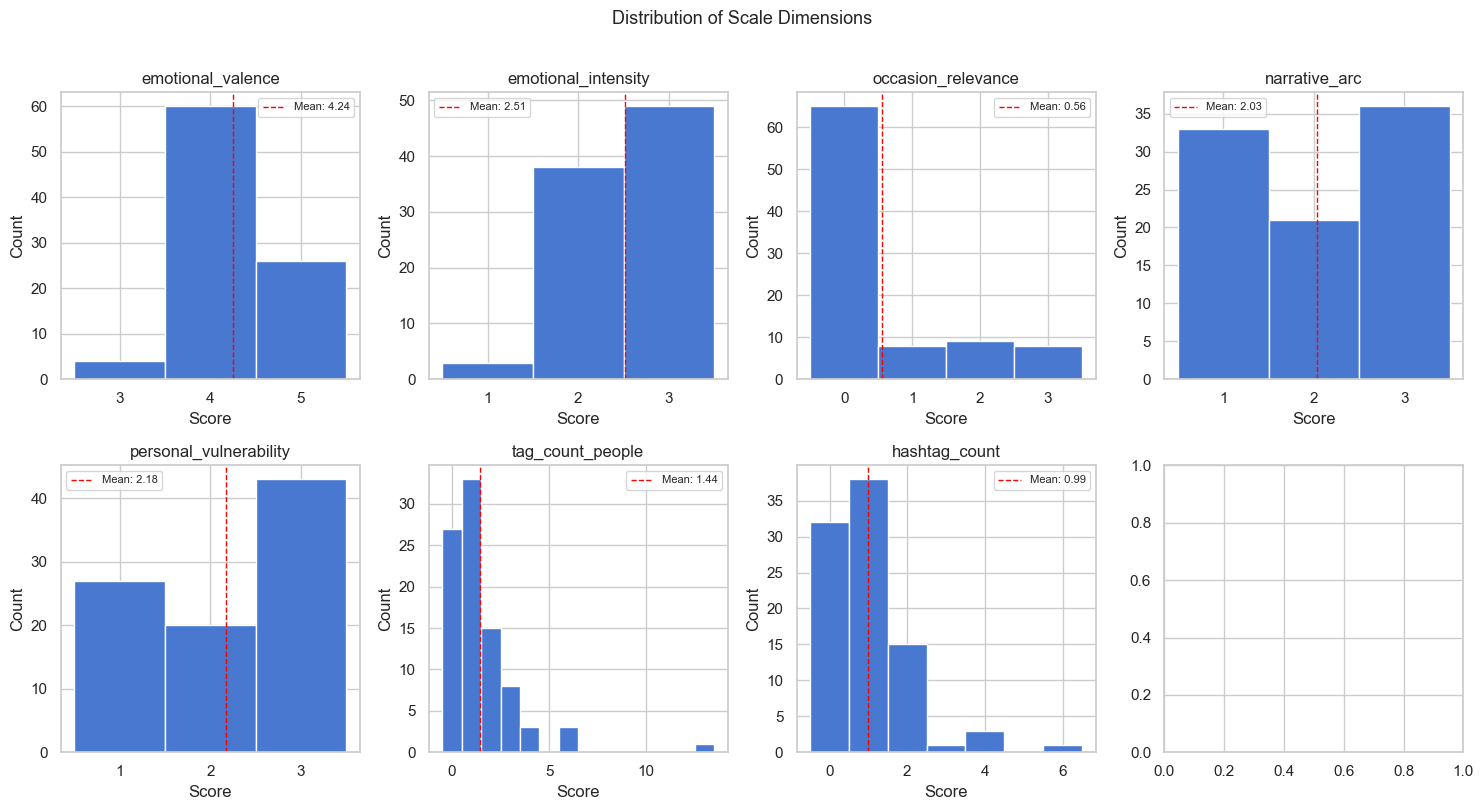

In [6]:
fig, axes = plt.subplots(2, 4, figsize=(15, 8))
for ax, col in zip(axes.flat, SCALE_DIMS):
    data = dft[col].dropna()
    ax.hist(data, bins=range(int(data.min()), int(data.max())+2),
            color=sns.color_palette('muted')[0], edgecolor='white', align='left')
    ax.axvline(data.mean(), color='red', linestyle='--', linewidth=1,
               label=f'Mean: {data.mean():.2f}')
    ax.set_title(col); ax.set_xlabel('Score'); ax.set_ylabel('Count'); ax.legend(fontsize=8)
plt.suptitle('Distribution of Scale Dimensions', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

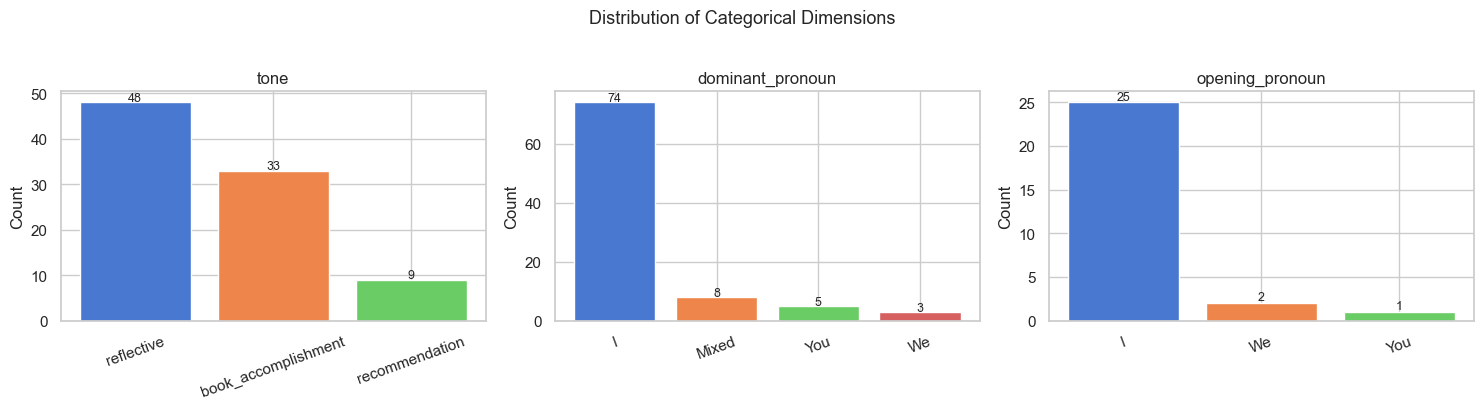

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, CAT_DIMS):
    counts = dft[col].value_counts()
    ax.bar(counts.index, counts.values, color=sns.color_palette('muted', len(counts)))
    ax.set_title(col); ax.set_ylabel('Count'); ax.tick_params(axis='x', rotation=20)
    for j, v in enumerate(counts.values): ax.text(j, v+0.3, str(v), ha='center', fontsize=9)
plt.suptitle('Distribution of Categorical Dimensions', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

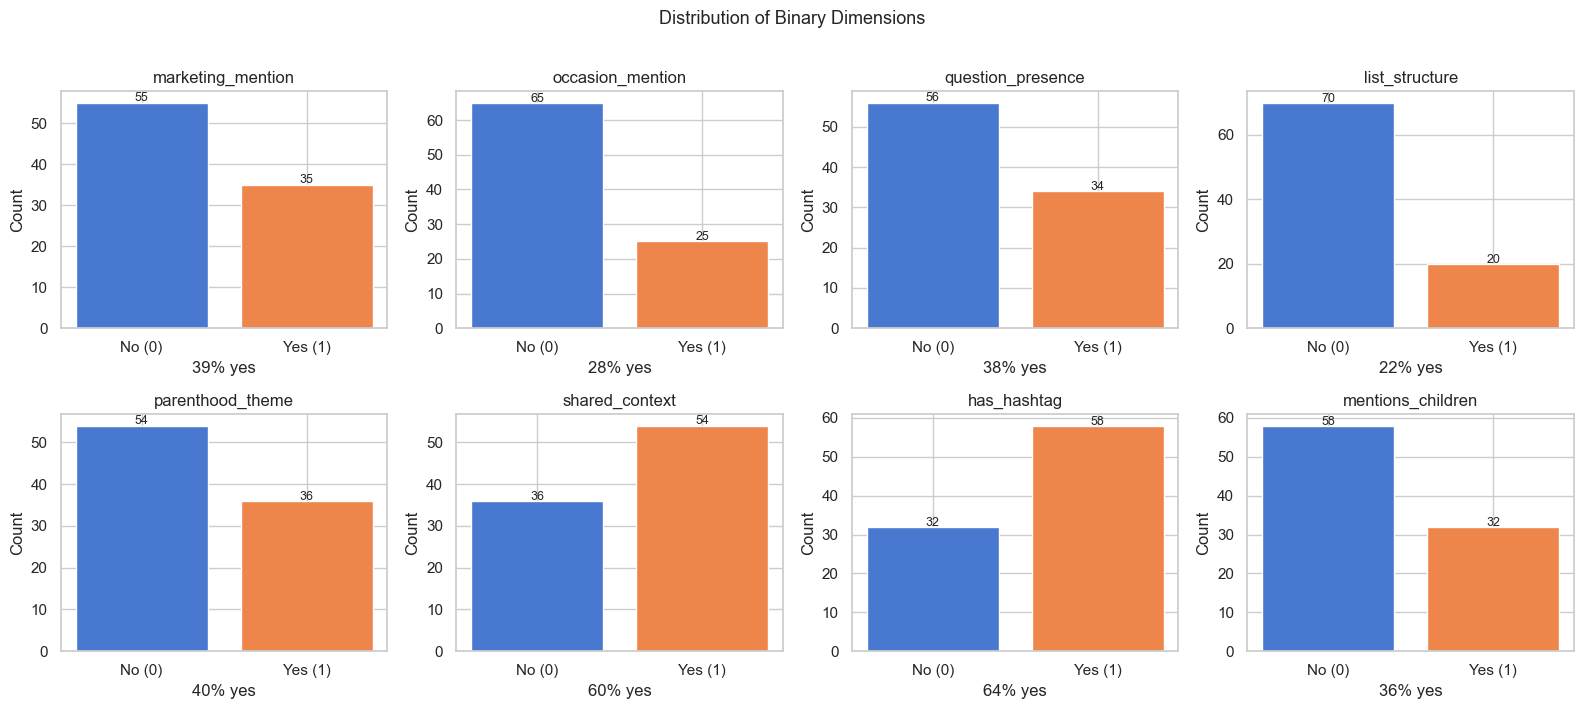

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, BINARY_DIMS):
    if col not in dft.columns: ax.set_visible(False); continue
    counts = dft[col].value_counts().sort_index()
    ax.bar(['No (0)', 'Yes (1)'][:len(counts)], counts.values,
           color=sns.color_palette('muted', 2))
    ax.set_title(col); ax.set_ylabel('Count'); ax.set_xlabel(f'{dft[col].mean():.0%} yes')
    for j, v in enumerate(counts.values): ax.text(j, v+0.3, str(v), ha='center', fontsize=9)
plt.suptitle('Distribution of Binary Dimensions', fontsize=13, y=1.01)
plt.tight_layout(); plt.show()

## 5. Correlation Matrix — Text Features × Text Features

Identify redundant dimensions (|r| > 0.7). These will be removed in section 6 
before analyzing relationships with engagement.

Also check our prediction: are `occasion_mention` and `shared_context` 
highly correlated as expected?

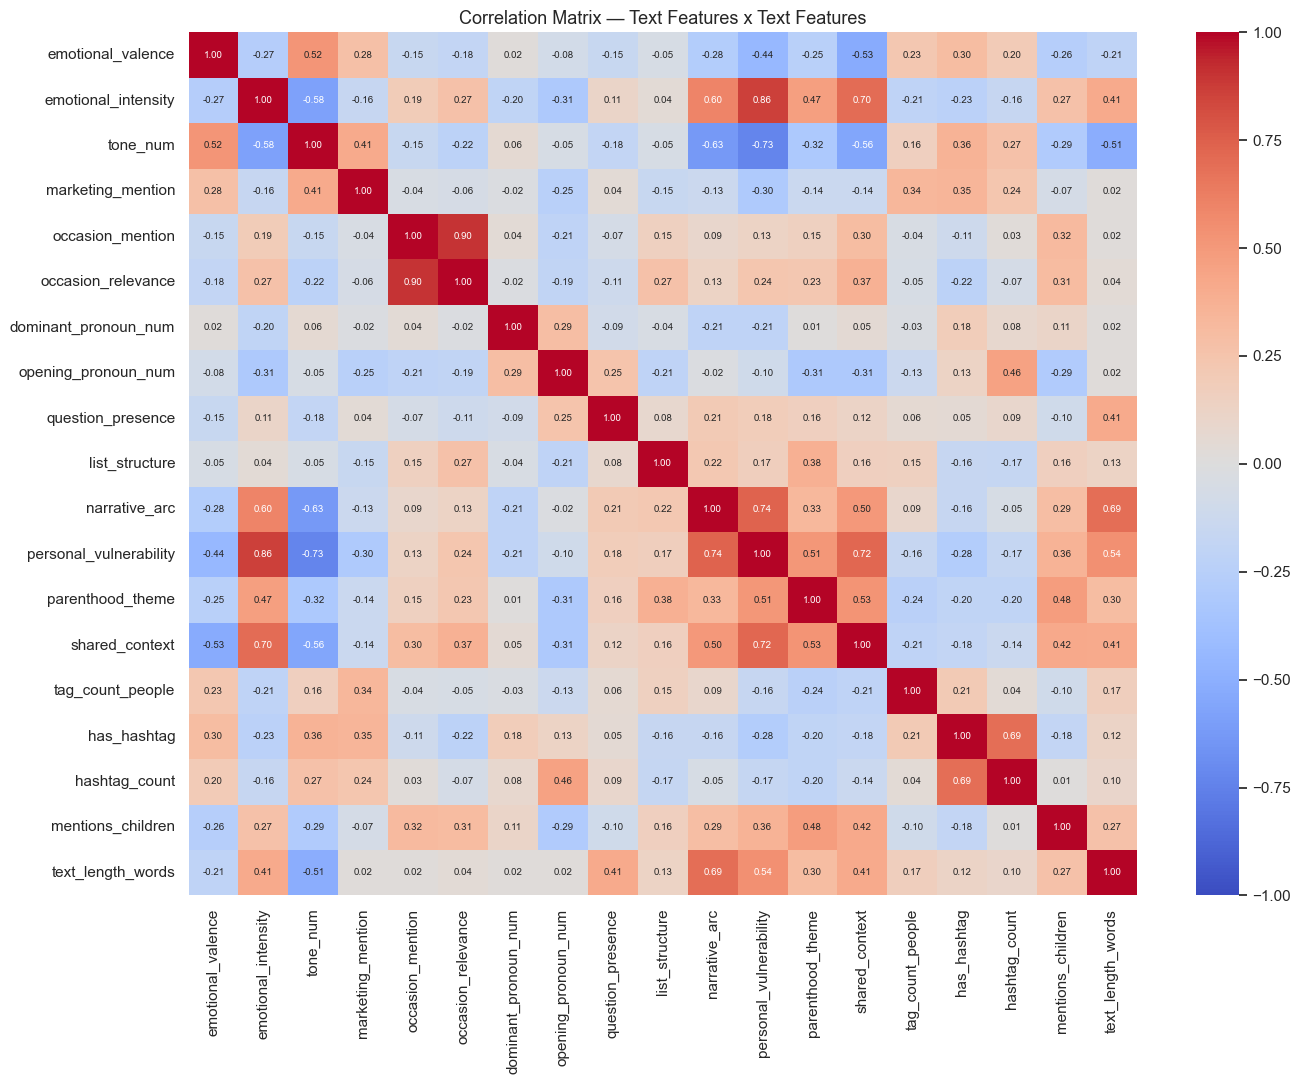

Pairs with |r| > 0.6:
  emotional_intensity            x personal_vulnerability         r=0.86
  emotional_intensity            x shared_context                 r=0.70
  tone_num                       x narrative_arc                  r=-0.63
  tone_num                       x personal_vulnerability         r=-0.73
  occasion_mention               x occasion_relevance             r=0.90
  narrative_arc                  x personal_vulnerability         r=0.74
  narrative_arc                  x text_length_words              r=0.69
  personal_vulnerability         x shared_context                 r=0.72
  has_hashtag                    x hashtag_count                  r=0.69


In [15]:
dft_enc = dft.copy()
dft_enc['tone_num']             = dft_enc['tone'].map({'reflective':0,'recommendation':1,'book_accomplishment':2,'occasion_anchored':3})
dft_enc['dominant_pronoun_num'] = dft_enc['dominant_pronoun'].map({'I':0,'You':1,'We':2,'Mixed':np.nan})
dft_enc['opening_pronoun_num']  = dft_enc['opening_pronoun'].map({'I':0,'You':1,'We':2,'None': np.nan})

ALL_DIMS_NUM = [
    'emotional_valence','emotional_intensity','tone_num',
    'marketing_mention','occasion_mention','occasion_relevance',
    'dominant_pronoun_num','opening_pronoun_num','question_presence',
    'list_structure','narrative_arc','personal_vulnerability',
    'parenthood_theme','shared_context','tag_count_people',
    'has_hashtag','hashtag_count','mentions_children','text_length_words'
]

corr_text = dft_enc[ALL_DIMS_NUM].corr().round(2)
fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_text, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size':7})
ax.set_title('Correlation Matrix — Text Features x Text Features', fontsize=13)
plt.tight_layout(); plt.show()

print('Pairs with |r| > 0.6:')
found = False
for i in range(len(corr_text.columns)):
    for j in range(i+1, len(corr_text.columns)):
        r = corr_text.iloc[i,j]
        if abs(r) > 0.6:
            print(f'  {corr_text.columns[i]:<30} x {corr_text.columns[j]:<30} r={r:.2f}')
            found = True
if not found: print('  No pairs above threshold.')

## 6. Variable Selection — Remove Redundant Dimensions

Based on the correlations above, decide which variables to keep. For each highly 
correlated pair (|r| > 0.7), keep the more theoretically meaningful or reliably 
measured variable. Document your reasoning in comments.

This final list flows into sections 7 and 8.

In [16]:
# UPDATE THIS LIST based on the correlation results above
# For each highly correlated pair, keep the more meaningful variable
# and comment out the redundant one with your reasoning

FINAL_DIMS = [
    'emotional_valence',
    # 'emotional_intensity',  # removed — correlated with personal_vulnerability (r=0.86)
    'tone_num',
    'marketing_mention',
    'occasion_relevance',   # kept over occasion_mention — superset of the binary
    # 'occasion_mention',   # removed — fully captured by occasion_relevance (r=0.91)
    'dominant_pronoun_num',
    'opening_pronoun_num',     # remove if correlated with dominant_pronoun_num
    'question_presence',
    'list_structure',
    'narrative_arc',
    'personal_vulnerability',
    'parenthood_theme',
    'shared_context',
    'tag_count_people',
    'has_hashtag',             # keep over hashtag_count if correlated
    'mentions_children',
    'text_length_words',
    # Removed: occasion_mention, hashtag_count, text_length_chars
]

print(f'Final feature set: {len(FINAL_DIMS)} dimensions')
print(FINAL_DIMS)

Final feature set: 16 dimensions
['emotional_valence', 'tone_num', 'marketing_mention', 'occasion_relevance', 'dominant_pronoun_num', 'opening_pronoun_num', 'question_presence', 'list_structure', 'narrative_arc', 'personal_vulnerability', 'parenthood_theme', 'shared_context', 'tag_count_people', 'has_hashtag', 'mentions_children', 'text_length_words']


## 7. Text Features × Post Category

How do text features differ across the four performance categories? 
This gives intuitive insight before running the formal predictive model.

/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_86022/1767762773.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace(' ','\n') for c in category_order
/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_86022/1767762773.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace(' ','\n') for c in category_order
/var/folders/cp/q5gmcd1n3jx17g259d775h8r0000gn/T/ipykernel_86022/1767762773.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[c.replace(' ','\n') for c in category_order


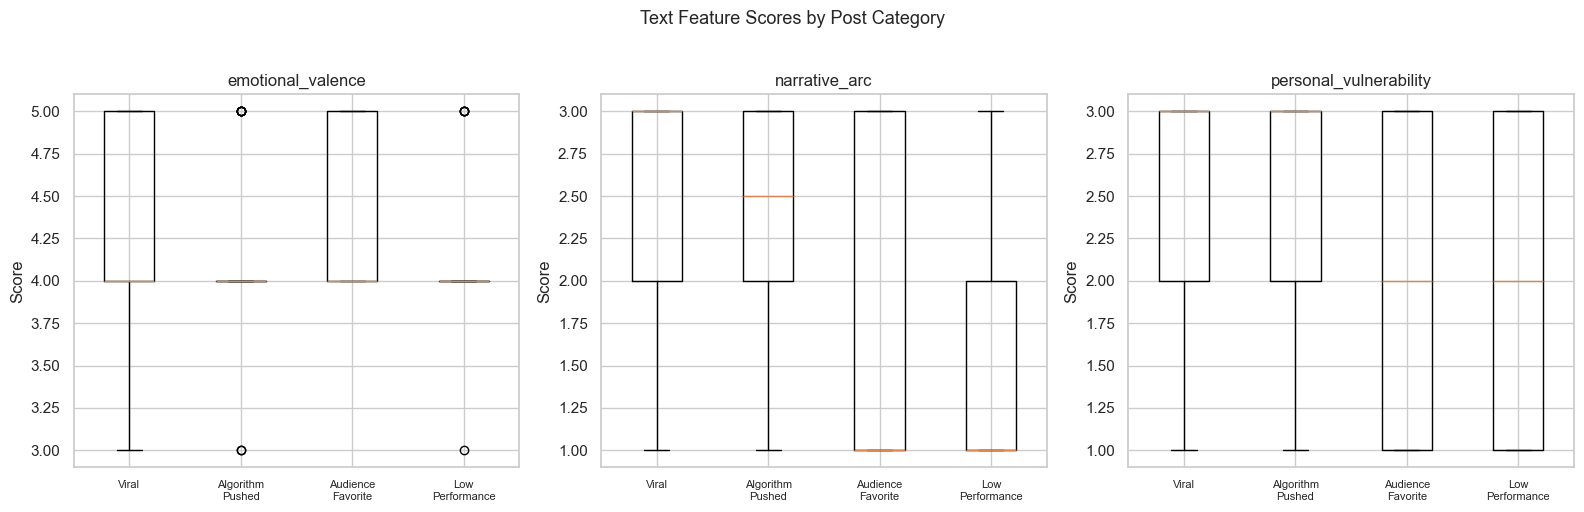

In [17]:
category_order = ['Viral', 'Algorithm Pushed', 'Audience Favorite', 'Low Performance']
scale_plot = [d for d in ['emotional_valence','emotional_intensity',
                           'narrative_arc','personal_vulnerability']
              if d in FINAL_DIMS]

fig, axes = plt.subplots(1, len(scale_plot), figsize=(16, 5))
for ax, col in zip(axes, scale_plot):
    data = [dft[dft['post_category']==cat][col].dropna()
            for cat in category_order if cat in dft['post_category'].values]
    ax.boxplot(data, labels=[c.replace(' ','\n') for c in category_order
                              if c in dft['post_category'].values])
    ax.set_title(col); ax.set_ylabel('Score'); ax.tick_params(axis='x', labelsize=8)
plt.suptitle('Text Feature Scores by Post Category', fontsize=13, y=1.02)
plt.tight_layout(); plt.show()

In [18]:
binary_final = [d for d in BINARY_DIMS if d in FINAL_DIMS and d in dft.columns]
cat_rates = dft.groupby('post_category')[binary_final].mean().round(3) * 100
print('% of posts with feature=1 by post category:')
display(cat_rates.reindex([c for c in category_order if c in cat_rates.index]))

% of posts with feature=1 by post category:


,marketing_mention,question_presence,list_structure,parenthood_theme,shared_context,has_hashtag,mentions_children
post_category,,,,,,,
Viral,50.0,31.8,31.8,59.1,72.7,77.3,36.4
Algorithm Pushed,19.2,42.3,15.4,38.5,61.5,46.2,30.8
Audience Favorite,60.9,47.8,17.4,34.8,56.5,65.2,43.5
Low Performance,26.3,26.3,26.3,26.3,47.4,73.7,31.6


## 8. Correlation Matrix — Text Features × Engagement Metrics

Using the final selected feature set only.

- **Engagement rate** = audience resonance after seeing the post
- **View-through rate** = whether people stopped scrolling to look

Different features may predict each outcome.

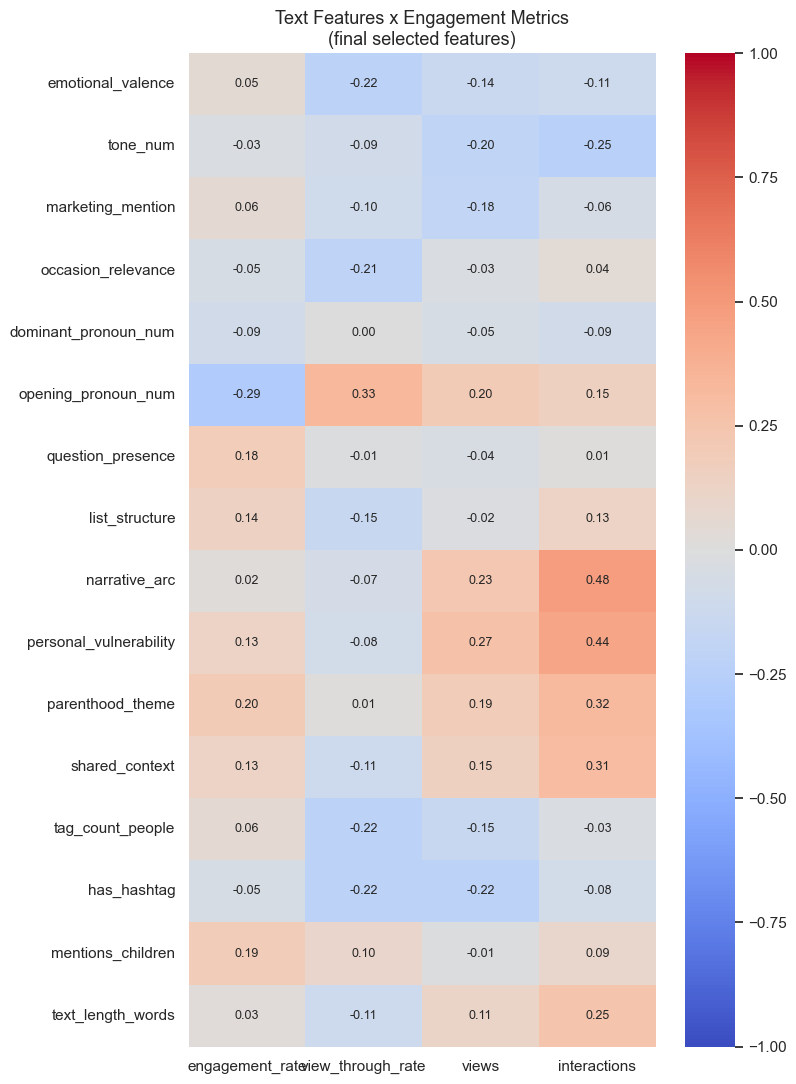

Top correlations with engagement_rate:
opening_pronoun_num      -0.29
parenthood_theme          0.20
mentions_children         0.19
question_presence         0.18
list_structure            0.14
personal_vulnerability    0.13
shared_context            0.13
dominant_pronoun_num     -0.09

Top correlations with view_through_rate:
opening_pronoun_num    0.33
emotional_valence     -0.22
tag_count_people      -0.22
has_hashtag           -0.22
occasion_relevance    -0.21
list_structure        -0.15
shared_context        -0.11
text_length_words     -0.11

Top correlations with interactions:
narrative_arc             0.48
personal_vulnerability    0.44
parenthood_theme          0.32
shared_context            0.31
tone_num                 -0.25
text_length_words         0.25
opening_pronoun_num       0.15
list_structure            0.13


In [21]:
corr_full   = dft_enc[FINAL_DIMS + OUTCOME_DIMS].corr().round(2)
corr_subset = corr_full.loc[FINAL_DIMS, OUTCOME_DIMS]

fig, ax = plt.subplots(figsize=(8, 11))
sns.heatmap(corr_subset, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, ax=ax, annot_kws={'size':9})
ax.set_title('Text Features x Engagement Metrics\n(final selected features)', fontsize=13)
plt.tight_layout(); plt.show()

print('Top correlations with engagement_rate:')
print(corr_subset['engagement_rate'].sort_values(key=abs, ascending=False).head(8).to_string())
print()
print('Top correlations with view_through_rate:')
print(corr_subset['view_through_rate'].sort_values(key=abs, ascending=False).head(8).to_string())
print()
print('Top correlations with interactions:')
print(corr_subset['interactions'].sort_values(key=abs, ascending=False).head(8).to_string())

## 9. Key Observations

Update this cell after reviewing the results above. 
These observations inform feature selection in `04_modeling.ipynb`.

In [20]:
print('=' * 60)
print('  TEXT FEATURE SUMMARY')
print('=' * 60)
print(f'  Posts analyzed:          {len(dft)}')
print(f'  LLM dimensions scored:   {len(LLM_DIMS)}')
print(f'  Final selected features: {len(FINAL_DIMS)}')
print()
print('  Most common tone:        ', dft['tone'].value_counts().index[0])
print('  Most common pronoun:     ', dft['dominant_pronoun'].value_counts().index[0])
print(f'  Posts with occasion:      {dft["occasion_mention"].sum()} ({dft["occasion_mention"].mean():.0%})')
print(f'  Posts with shared ctx:    {dft["shared_context"].sum()} ({dft["shared_context"].mean():.0%})')
print(f'  Posts with question:      {dft["question_presence"].sum()} ({dft["question_presence"].mean():.0%})')
print(f'  Posts with hashtag:       {dft["has_hashtag"].sum()} ({dft["has_hashtag"].mean():.0%})')
print()
top_eng = corr_subset['engagement_rate'].abs().sort_values(ascending=False)
top_vtr = corr_subset['view_through_rate'].abs().sort_values(ascending=False)
top_inter = corr_subset['interactions'].abs().sort_values(ascending=False)
print(f'  Top predictor engagement_rate:    {top_eng.index[0]} (r={corr_subset["engagement_rate"][top_eng.index[0]]:.2f})')
print(f'  Top predictor view_through_rate:  {top_vtr.index[0]} (r={corr_subset["view_through_rate"][top_vtr.index[0]]:.2f})')
print(f'  Top predictor interactions:  {top_inter.index[0]} (r={corr_subset["interactions"][top_inter.index[0]]:.2f})')
print('=' * 60)

  TEXT FEATURE SUMMARY
  Posts analyzed:          90
  LLM dimensions scored:   15
  Final selected features: 16

  Most common tone:         reflective
  Most common pronoun:      I
  Posts with occasion:      25 (28%)
  Posts with shared ctx:    54 (60%)
  Posts with question:      34 (38%)
  Posts with hashtag:       58 (64%)

  Top predictor engagement_rate:    opening_pronoun_num (r=-0.29)
  Top predictor view_through_rate:  opening_pronoun_num (r=0.33)
  Top predictor interactions:  narrative_arc (r=0.48)
